In [1]:
import torch
from torch import nn

import math
from matplotlib import pyplot as plt

from func.load_mnist import load_mnist
from func.validate_model import validate_model

from Model_BasicCNN import BasicCNN
from Model_TowardsBNN import TowardsBNN

In [2]:
train_dl, validate_dl = load_mnist()

In [3]:
def plot_sample_list(model, samples, labels):
    n = len(samples)
    grid_size = math.isqrt(n)
    if grid_size * grid_size != n:
        raise ValueError(f"Number of samples must be a perfect square, got {n}")

    model.eval()
    with torch.no_grad():
        batch = torch.stack([
            s if s.dim() == 3 else s.unsqueeze(0)
            for s in samples
        ])
        preds = model(batch).argmax(dim=1).tolist()

    fig, axes = plt.subplots(grid_size, grid_size,
                             figsize=(grid_size * 1.8, grid_size * 2.0))

    for idx, ax in enumerate(axes.flat):
        ax.imshow(samples[idx].squeeze().numpy(), cmap="gray", interpolation="nearest")
        title = f"{preds[idx]} "+("[✔]" if preds[idx]==labels[idx] else "[✘]")
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [4]:
def load_model(model:nn.Module):
  model_name = type(model).__name__
  state_dict = torch.load(f"data/model_weights/{model_name}.pnn")
  model.load_state_dict(state_dict)
  return model


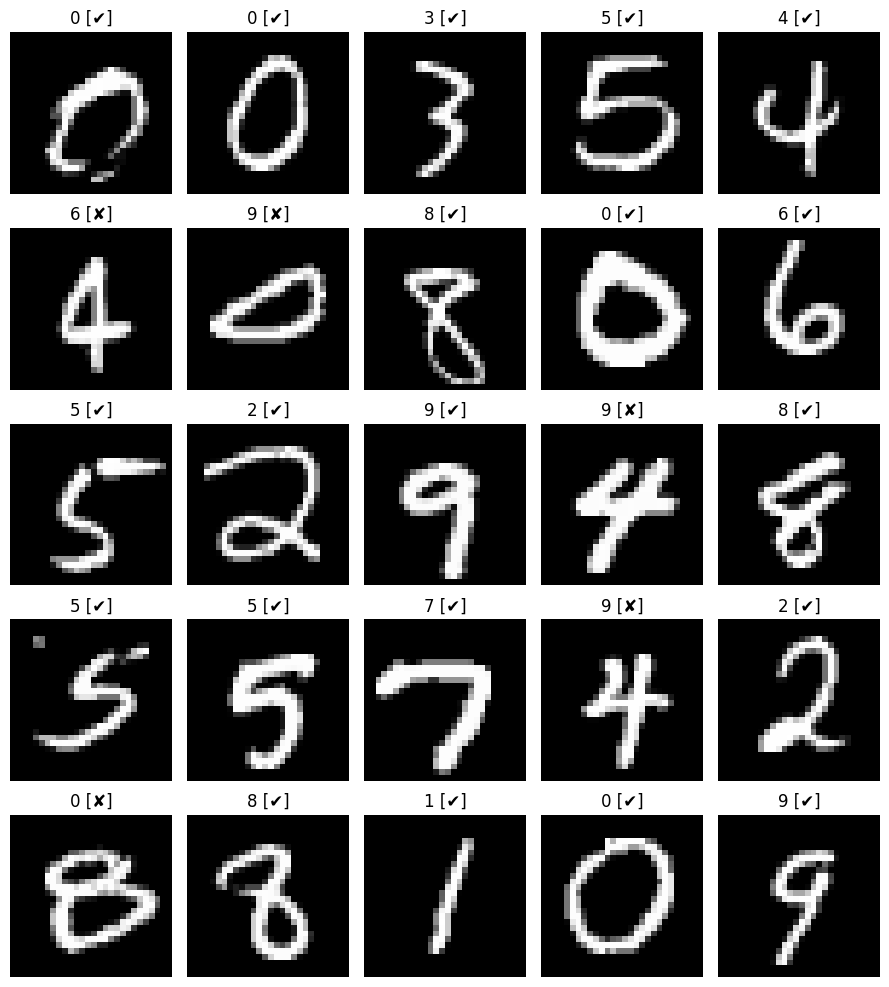

In [5]:
images, labels = next(iter(validate_dl))
samples = list(images[:25])

model = load_model(
  TowardsBNN()
)
plot_sample_list(model, samples, labels)

In [6]:
labels

tensor([0, 0, 3,  ..., 2, 1, 1])

In [7]:
# Shift parameter of TowardsBNN
list(model.preprocess[0].parameters())

[Parameter containing:
 tensor(0.2721, requires_grad=True)]

-----------------------------------------------------------------------------------------------

In [8]:
model

TowardsBNN(
  (preprocess): Sequential(
    (0): LearnableShift()
    (1): QuantizeBinary()
  )
  (features): Sequential(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
    (2): QuantizeBinary()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (5): QuantizeBinary()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

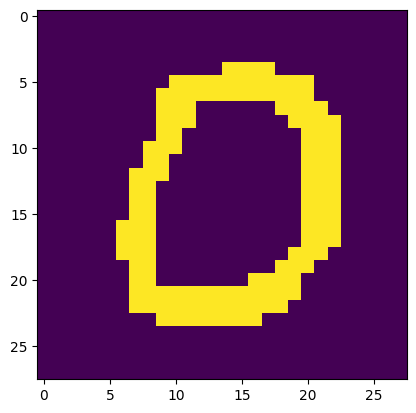

In [9]:


img, label = validate_dl.dataset.__getitem__(10)
img = img.unsqueeze(0)

img_prep = model.preprocess(img).detach()

interim_model = nn.Sequential(
  *[model.features[i] for i in range(3)]
)

img_interim = interim_model(img_prep).detach()

plt.imshow(img_prep.squeeze())

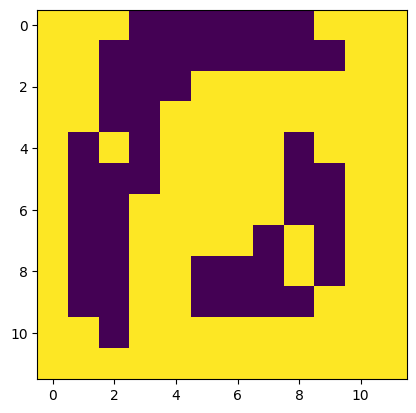

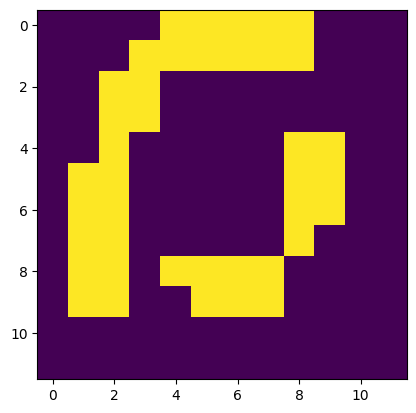

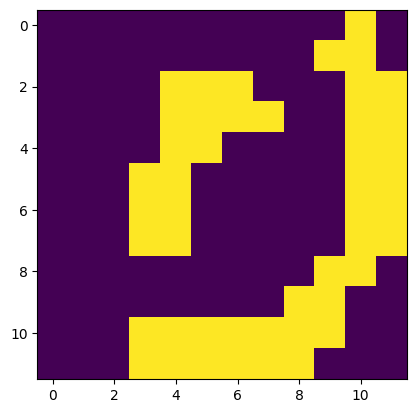

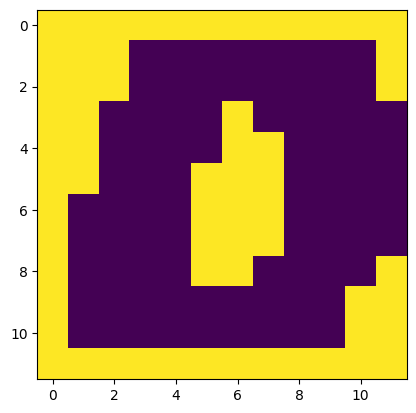

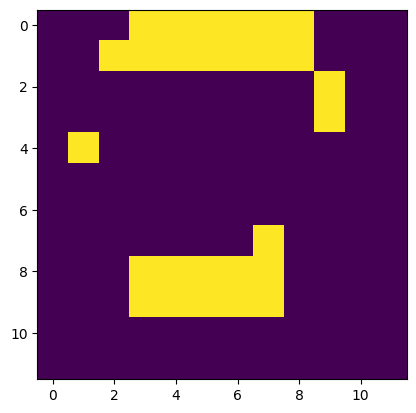

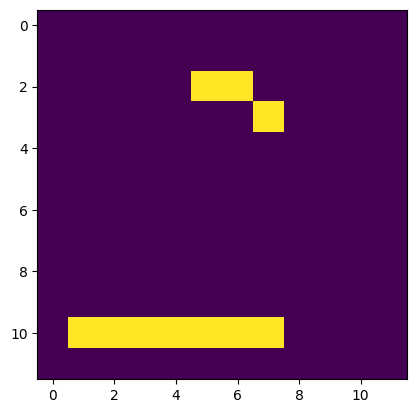

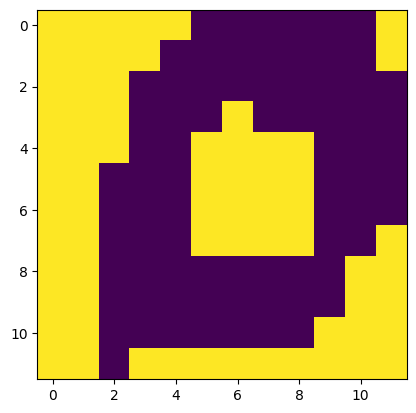

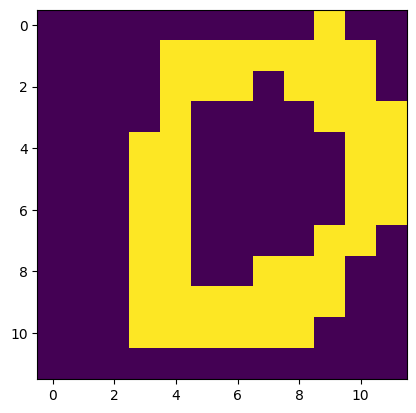

In [10]:
for feat in img_interim.squeeze():
  plt.imshow(feat)
  plt.show()

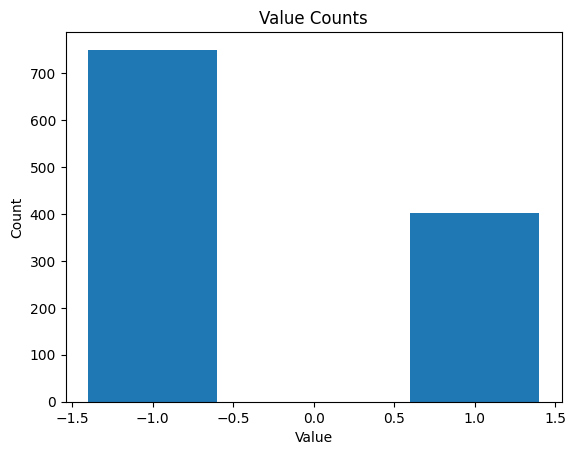

In [11]:
values, counts = torch.unique(img_interim, return_counts=True)

plt.bar(values.numpy(), counts.numpy())
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Value Counts")
plt.show()